#**VonHeijne algorithm**

#### Importing libraries and datasets





In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve
import math

In [3]:
positive = pd.read_csv("/content/positive_set.tsv", sep="\t")
negative = pd.read_csv("/content/negative_set.tsv", sep="\t")

positive["type"] = "Positive"
negative["type"] = "Negative"

print(positive["protein_id"].is_unique) #Checking if protein_id can be used as label
print(negative["protein_id"].is_unique)

positive = positive.set_index("protein_id")
negative = negative.set_index("protein_id")
positive = positive.rename(columns={"class": "dataset_class"})
negative = negative.rename(columns={"class": "dataset_class"})

tot = pd.concat([positive, negative])
new_tot = tot.copy()
new_tot = new_tot[["dataset_class",'cv_subset','type']]

new_tot["sequence"] = pd.Series("", index=new_tot.index)
new_tot["motif"] = pd.Series("", index=new_tot.index)

new_tot.head()

True
True


,dataset_class,cv_subset,type,sequence,motif
protein_id,,,,,
Q99MA2,Training,1,Positive,,
P17948,Training,1,Positive,,
P41271,Training,1,Positive,,
Q8I948,Training,1,Positive,,
Q92154,Training,1,Positive,,


#### Add sequence & motif to the dataframe

In [4]:
positive_seq_fasta = "/content/cluster-results_positive_rep_seq.fasta"
negative_seq_fasta = "/content/cluster-results_negative_rep_seq.fasta"
positive_motif = "/content/training_motif_alignment.fasta"

with open(positive_seq_fasta,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "sequence"] = line.strip()
      header = True
file.close()

with open(negative_seq_fasta,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "sequence"] = line.strip()
      header = True
file.close()

with open(positive_motif,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "motif"] = line.strip()
      header = True
file.close()

original = new_tot.copy()
#test = new_tot.copy()
original = original.query('dataset_class == "Training"')
#test = test.query('dataset_class == "Test"')

new_tot.drop("motif",axis=1).to_csv("SVM_data.tsv", sep="\t")
#test.drop("motif",axis=1).to_csv("test_set.tsv", sep="\t")



#### Split validation - training subsets
###### The input is the df +- training



In [36]:
def cv_subsets(df):
  subsets = set()
  for _, row in df.iterrows():
    index = row["cv_subset"]
    subsets.add(index)
  combinations={}
  for index in subsets:
    validation = index
    second = ((index+1)%5)+1
    training = [second]+list(subsets - {index, second})
    combinations[validation] = training
  return combinations

cv_subsets(original)


{1: [3, 2, 4, 5],
 2: [4, 1, 3, 5],
 3: [5, 1, 2, 4],
 4: [1, 2, 3, 5],
 5: [2, 1, 3, 4]}

#### Identify the splits between training, validation and testing data

In [22]:
def df_subset(df, combinations, index):
  l = combinations[index]
  training = l[1:]
  test = index
  print("test", test,"training",training)
  for id,row in df.iterrows():
    if row["cv_subset"] in training:
      df.loc[id, "dataset_class"] = "Training"
    elif row["cv_subset"] == test:
      df.loc[id, "dataset_class"] = "Testing"
    else:
      df.loc[id, "dataset_class"] = "Validation"
  return


#### Matrix generation

In [7]:
def matrix_generation(df):
  df = df.query('type == "Positive"')
  df_row_count = df.shape[0] # N number of rows
  shape_motif = (-13,2) #motif indexes
  #Matrix init with pseudocount
  matrix = {shape_motif[0]:{"A": 1, "Q": 1, "L": 1, "S": 1, "R": 1, "E": 1, "K": 1, "T": 1, "N": 1, "G": 1, "M": 1, "W": 1, "D": 1, "H": 1, "F": 1, "Y": 1, "C": 1, "I": 1, "P": 1, "V": 1}}
  for i in range(shape_motif[0]+1, shape_motif[1]):
    matrix[i] = {"A": 1, "Q": 1, "L": 1, "S": 1, "R": 1, "E": 1, "K": 1, "T": 1, "N": 1, "G": 1, "M": 1, "W": 1, "D": 1, "H": 1, "F": 1, "Y": 1, "C": 1, "I": 1, "P": 1, "V": 1}

  #Counting aa occurences
  for _, row in df.iterrows():
    motif = str(row["motif"])
    for index,aa in enumerate(motif):
      if aa == "X" or aa == "n" or aa == "a" or aa == "U":
        continue
      matrix[index-13][aa] += 1

  #Dividing for N + 20
  for key, value in matrix.items():
    for index, aa in matrix[key].items():
      matrix[key][index] = (aa/(df_row_count+20))

  #Transformation into a pd df
  matrix_df = pd.DataFrame.from_dict(matrix, orient='index')
  reference = {"A": 0.0825, "Q": 0.0393, "L": 0.0964, "S": 0.0665, "R": 0.0552, "E": 0.0671, "K": 0.0579, "T": 0.0536, "N": 0.0406, "G": 0.0707, "M": 0.0241, "W": 0.0110, "D": 0.0546, "H": 0.0227, "F": 0.0386, "Y": 0.0292, "C": 0.0138, "I": 0.0590, "P": 0.0474, "V": 0.0685}

  #Dividing for reference
  for _,row in matrix_df.iterrows():
    for aa, value in reference.items():
      row[aa] = row[aa]/value

  #Apply log
  matrix_df = matrix_df.apply(np.log)
  return matrix_df


#### Score prediction of an entry using the matrix

In [8]:
def score_prediction(matrix, entry):
  score = 0
  best_score = -100000000000000000000000000000000000000
  seq = entry["sequence"]
  l = 15
  for index in range(91):
    motif = seq[index:index+l]
    position = -13
    for residue in motif:
      if residue == "X" or residue == "n" or residue == "a" or residue == "U":
        continue
      score += matrix.loc[position][residue]
      position+=1
    if score > best_score:
      best_score = score
  return best_score

#### Threshold estimation

In [9]:
def threshold_estimation(df):
  y_validation = []
  entry_types = df["type"]
  for entry in entry_types:
    if entry == "Positive":
      y_validation.append(1)
    else:
      y_validation.append(0)
  y_validation_scores = []
  for id,row in df.iterrows():
     entry_score = score_prediction(w, row)
     y_validation_scores.append(entry_score)
  precision, recall, thresholds = precision_recall_curve(y_validation, y_validation_scores)
  fscore = (2 * precision * recall) / (precision + recall)
  index = np.argmax(fscore)
  optimal_threshold = thresholds[index]
  return optimal_threshold

#### Classification of an entry based on its score

In [11]:
def classification(score, threshold):
  if score >= threshold:
    entry_class = "Positive"
  else:
    entry_class = "Negative"
  return entry_class

#### Computing performance metrics

In [12]:
def performance_metrics(df):
  TP = FN = FP = TN = 1
  for id,row in df.iterrows():
    real = row["type"]
    predicted = row["predicted"]
    if real == "Positive" and predicted == "Positive":
      TP += 1
    elif real == "Positive" and predicted == "Negative":
      FN += 1
    elif real == "Negative" and predicted == "Positive":
      FP += 1
    elif real == "Negative" and predicted == "Negative":
      TN += 1
  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  f1_score = 2*precision*recall / (precision + recall)
  accuracy = (TP + TN) / (TP + TN + FP + FN)
  mcc = (((TP * TN) - (FP * FN))/math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
  print("TP:", TP," FP:",FP," TN:",TN," FN:",FN)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 score:", f1_score)
  print("Accuracy:", accuracy)
  print("MCC:",mcc)
  return [precision,recall,f1_score,accuracy,mcc]

#### Final execution

In [37]:
combinations = cv_subsets(original) # validation : training
#combinations = {1: [2, 3, 4, 5]}
metrics_tot = []
threshold_tot = []

for index in combinations: #for every cross validation subset
  print("Training on cv: ", combinations[index][1:], " Validating on cv: ", combinations[index][0], " Testing on cv: ", index)
  df_subset(original, combinations, index)
  training = original.copy()
  training = training.query('dataset_class == "Training"')
  w = matrix_generation(training)
  print("Matrix generated")
  print(w)

  print("Validation")
  validation = original.copy()
  validation = validation.query('dataset_class == "Validation"')
  validation["predicted"] = pd.Series("", index=new_tot.index)
  threshold = threshold_estimation(validation)
  threshold_tot.append(threshold)
  print("Threshold: ",threshold)
  for id,row in validation.iterrows():
     entry_score = score_prediction(w, row)
     validation.loc[id, "predicted"] = classification(entry_score, threshold)

  print("Testing")
  testing = original.copy()
  testing = testing.query('dataset_class == "Testing"')
  testing["predicted"] = pd.Series("", index=new_tot.index)
  for id,row in testing.iterrows():
     entry_score = score_prediction(w, row)
     testing.loc[id, "predicted"] = classification(entry_score, threshold)

  print("Performance metrics on testing: ")
  metrics = performance_metrics(testing)
  metrics_tot.append(metrics)

  print("Finished")
  print()
  print("------------------------------------")
  print()

print("FINISHED EVERY CV")
for i in metrics_tot:
  print(i)

Training on cv:  [2, 4, 5]  Validating on cv:  3  Testing on cv:  1
test 1 training [2, 4, 5]
Matrix generated
            A         Q         L         S         R         E         K  \
-13  0.254614 -1.965643  1.395050 -0.258028 -1.794556 -2.500602 -2.758601   
-12  0.237222 -3.064255  1.467809 -0.699861 -3.403993 -3.599215 -2.353136   
-11  0.145415 -1.272496  1.390321 -0.412179 -2.710846 -2.906067 -3.451748   
-10  0.125997 -1.677961  1.361473 -0.093725 -2.017699 -2.906067 -2.758601   
-9   0.857610 -1.454817  1.311463  0.020685 -2.305381 -1.989777 -3.451748   
-8   0.636822 -1.118345  1.081888  0.280969 -2.305381 -1.989777 -2.758601   
-7   0.271709 -0.666360  1.247949 -0.063872 -1.612234 -1.519773 -1.842310   
-6   0.613012 -1.677961  0.774662 -0.156245 -1.612234 -2.212920 -2.353136   
-5   0.737466  0.369732 -0.435176  0.599422 -0.919087 -0.708843 -1.254523   
-4   0.201504 -0.068523  0.382269  0.487305 -0.513622 -0.654776 -1.053853   
-3   1.114152 -3.064255 -0.783483  0.74050

#### Printing overall performances

In [38]:
precision=[]
recall=[]
f1_score=[]
accuracy=[]
mcc=[]

for i in metrics_tot:
  precision.append(i[0])
  recall.append(i[1])
  f1_score.append(i[2])
  accuracy.append(i[3])
  mcc.append(i[4])

metrics_df = pd.DataFrame({"Precision": precision, "Recall": recall, "F1 score": f1_score, "Accuracy": accuracy, "MCC": mcc, "Thresholds":threshold_tot})
print(metrics_df.head())
print()
metrics_description = metrics_df.describe()
plus_minus = "\u00b1"
print("Precision: ",round(metrics_description["Precision"]["mean"],4),plus_minus,round(metrics_description["Precision"]["std"],4))
print("Recall: ",round(metrics_description["Recall"]["mean"],4),plus_minus,round(metrics_description["Recall"]["std"],4))
print("F1 score: ",round(metrics_description["F1 score"]["mean"],4),plus_minus,round(metrics_description["F1 score"]["std"],4))
print("Accuracy: ",round(metrics_description["Accuracy"]["mean"],4),plus_minus,round(metrics_description["Accuracy"]["std"],4))
print("MCC: ",round(metrics_description["MCC"]["mean"],4),plus_minus,round(metrics_description["MCC"]["std"],4))
print("Threshold: ",round(metrics_description["Thresholds"]["mean"],4),plus_minus,round(metrics_description["Thresholds"]["std"],4))

   Precision    Recall  F1 score  Accuracy       MCC  Thresholds
0   0.764286  0.604520  0.675079  0.935945  0.645503    7.068030
1   0.770370  0.587571  0.666667  0.935323  0.638680   10.554271
2   0.737430  0.745763  0.741573  0.942786  0.709420    5.093300
3   0.767442  0.559322  0.647059  0.932836  0.620295    7.249817
4   0.811024  0.581921  0.677632  0.939130  0.655871   13.098985

Precision:  0.7701 ± 0.0264
Recall:  0.6158 ± 0.0744
F1 score:  0.6816 ± 0.0356
Accuracy:  0.9372 ± 0.0038
MCC:  0.654 ± 0.0336
Threshold:  8.6129 ± 3.183


#### Heatmap of the last w matrix

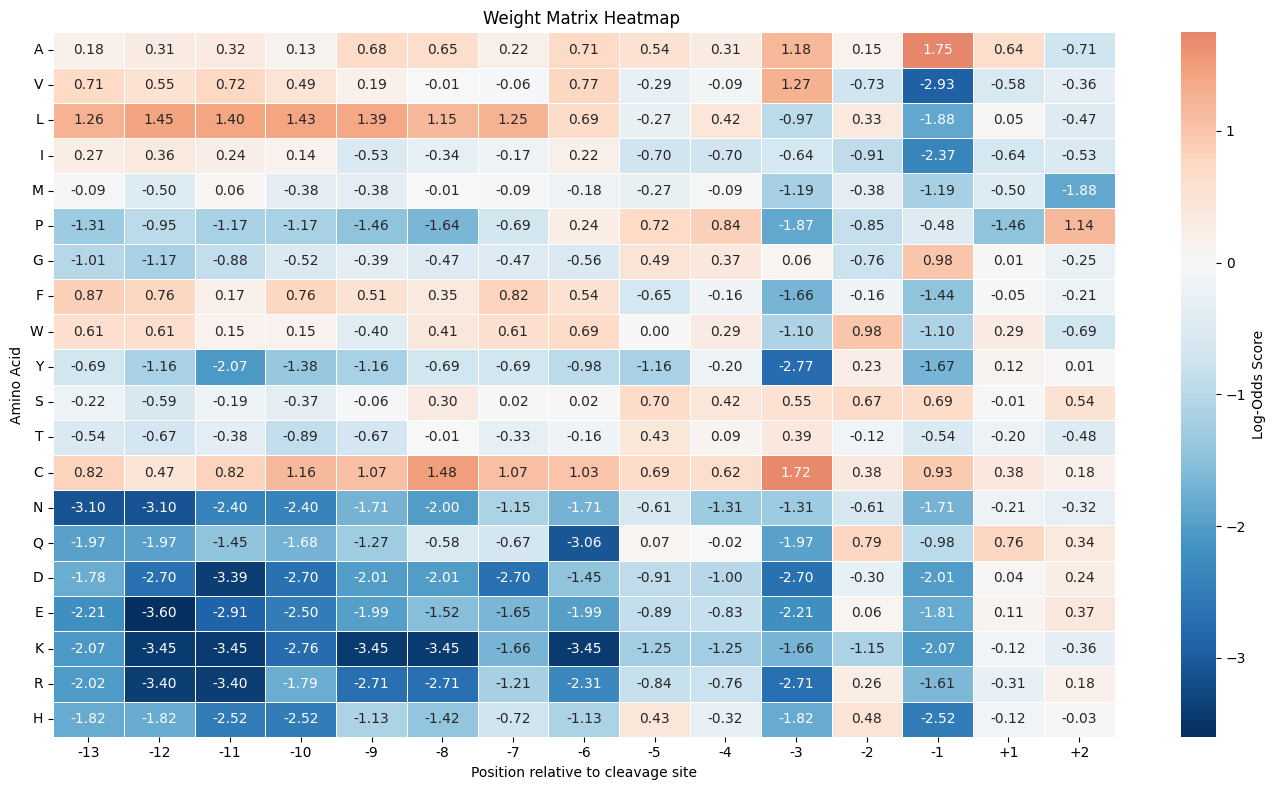

In [39]:
#### Heatmap visualization of the Weight Matrix
import seaborn as sns
import matplotlib.pyplot as plt

#amminoacidi ordinati
aa_groups = {
    "Apolar":   ["A", "V", "L", "I", "M", "P", "G"],
    "Aromatic": ["F", "W", "Y"],
    "Polar":    ["S", "T", "C", "N", "Q"],
    "Charged":  ["D", "E", "K", "R", "H"]
}
aa_order = [aa for group in aa_groups.values() for aa in group]

# Prepariamo i dati
# Trasponiamo w  -> Y=Amminoacidi, X=Posizioni
# indice righe = gruppo chimico
w_sorted = w.T.reindex(aa_order)

#Heatmap
plt.figure(figsize=(14, 8))
ax = sns.heatmap(w_sorted,
            cmap="RdBu_r",    # Red=Positive (Enriched) vs Blue=Negative (Depleted)
            center=0,         # bianco = 0 = background frequency
            annot=True,
            fmt=".2f",
            linewidths=.5,
            linecolor='white',
            cbar_kws={'label': 'Log-Odds Score'})

plt.title("Weight Matrix Heatmap ")
plt.xlabel("Position relative to cleavage site")
plt.ylabel("Amino Acid")

# Sovrascriviamo le etichette dell'asse X
bio_labels = [str(i) for i in range(-13, 0)] + ["+1", "+2"]
ax.set_xticklabels(bio_labels)

# Aggiustiamo le etichette per mostrare i gruppi
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("w_matrix_heatmap.png")
plt.show()

#### Precision recall curve

In [40]:
# --- Blocco Final Execution con raccolta dati per PR Curve ---

combinations = cv_subsets(original) # validation : training

metrics_tot = []
threshold_tot = []

# [MODIFICA 1] Inizializziamo le liste per salvare i dati grezzi per il grafico
results_true = []   # Conterrà le etichette vere (0/1) per ogni fold
results_scores = [] # Conterrà gli score numerici predetti per ogni fold

for index in combinations: #for every cross validation subset
  print("Training on cv: ", combinations[index][1:], " Validating on cv: ", combinations[index][0], " Testing on cv: ", index)

  df_subset(original, combinations, index)

  training = original.copy()
  training = training.query('dataset_class == "Training"')
  w = matrix_generation(training)
  print("Matrix generated")
  # print(w) # Decommenta se vuoi vedere la matrice ogni volta

  print("Validation")
  # [CONSIGLIO] Aggiunto .copy() per evitare SettingWithCopyWarning
  validation = original.query('dataset_class == "Validation"').copy()
  # [CORREZIONE] Usa validation.index per sicurezza, invece di new_tot.index
  validation["predicted"] = pd.Series("", index=validation.index)

  threshold = threshold_estimation(validation)
  threshold_tot.append(threshold)
  print("Threshold: ", threshold)

  for id, row in validation.iterrows():
     entry_score = score_prediction(w, row)
     validation.loc[id, "predicted"] = classification(entry_score, threshold)

  print("Testing")
  testing = original.copy()
  testing = testing.query('dataset_class == "Testing"').copy() # Aggiunto .copy()
  testing["predicted"] = pd.Series("", index=testing.index) # Usa testing.index

  # [MODIFICA 2] Creiamo una colonna per salvare lo score numerico
  testing["score"] = 0.0

  for id, row in testing.iterrows():
     entry_score = score_prediction(w, row)

     # [MODIFICA 3] Salviamo lo score numerico nel dataframe
     testing.loc[id, "score"] = entry_score
     testing.loc[id, "predicted"] = classification(entry_score, threshold)

  # [MODIFICA 4] Estraiamo i dati di questo fold e li salviamo nelle liste globali
  # Convertiamo Positive/Negative in 1/0 per il grafico
  y_fold_true = testing["type"].apply(lambda x: 1 if x == "Positive" else 0).values
  y_fold_scores = testing["score"].values

  results_true.append(y_fold_true)
  results_scores.append(y_fold_scores)

  print("Performance metrics on testing: ")
  metrics = performance_metrics(testing)
  metrics_tot.append(metrics)

  print("Finished")
  print()
  print("------------------------------------")
  print()

print("FINISHED EVERY CV")
for i in metrics_tot:
  print(i)

Training on cv:  [2, 4, 5]  Validating on cv:  3  Testing on cv:  1
test 1 training [2, 4, 5]
Matrix generated
Validation
Threshold:  7.068030103007605
Testing
Performance metrics on testing: 
TP: 107  FP: 33  TN: 1398  FN: 70
Precision: 0.7642857142857142
Recall: 0.6045197740112994
F1 score: 0.6750788643533123
Accuracy: 0.9359452736318408
MCC: 0.6455033263500647
Finished

------------------------------------

Training on cv:  [1, 3, 5]  Validating on cv:  4  Testing on cv:  2
test 2 training [1, 3, 5]
Matrix generated
Validation
Threshold:  10.554270706167088
Testing
Performance metrics on testing: 
TP: 104  FP: 31  TN: 1400  FN: 73
Precision: 0.7703703703703704
Recall: 0.5875706214689266
F1 score: 0.6666666666666666
Accuracy: 0.9353233830845771
MCC: 0.6386804209316149
Finished

------------------------------------

Training on cv:  [1, 2, 4]  Validating on cv:  5  Testing on cv:  3
test 3 training [1, 2, 4]
Matrix generated
Validation
Threshold:  5.093300268284254
Testing
Performance

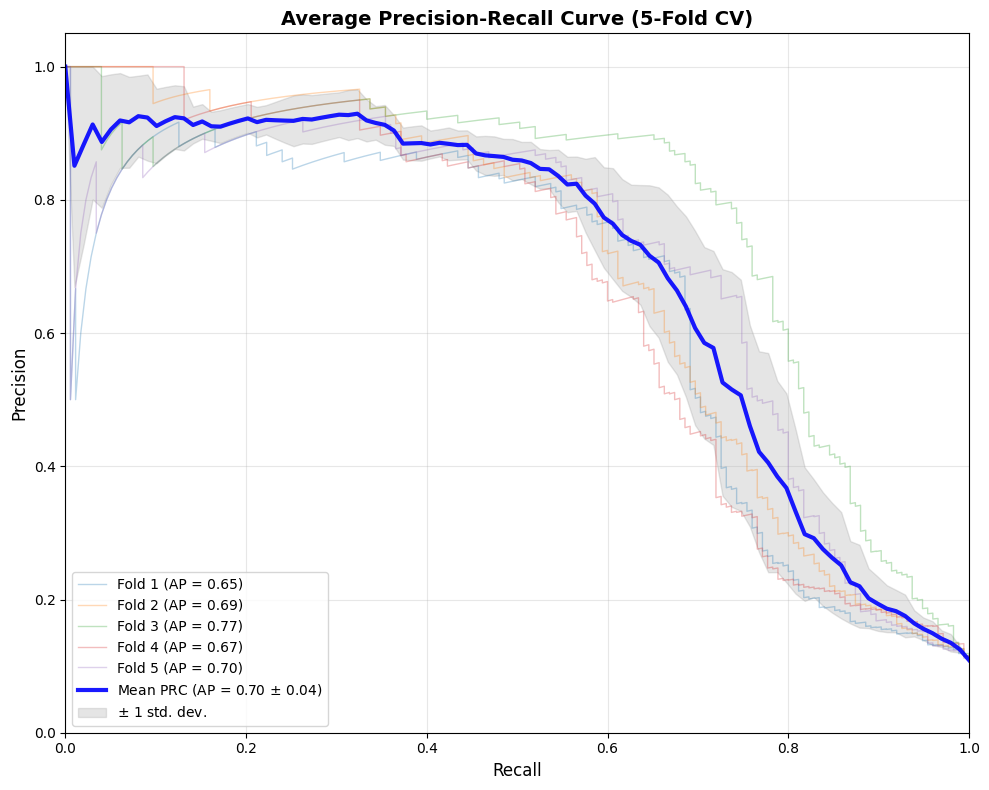

In [41]:
#### Average Precision-Recall Curve Visualization
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(10, 8))

# asse comune per il Recall (da 0 a 1) per poter fare la media
mean_recall = np.linspace(0, 1, 100)
precisions = []
aucs = []

# Ciclo sui 5 fold
for i in range(len(results_true)):
    # Calcolo della curva per il singolo fold
    precision, recall, _ = precision_recall_curve(results_true[i], results_scores[i])
    pr_auc = auc(recall, precision)
    aucs.append(pr_auc)

    # Plot della linea sottile per ogni fold
    plt.plot(recall, precision, lw=1, alpha=0.3, label=f'Fold {i+1} (AP = {pr_auc:.2f})')

    # Interpolazione: portiamo tutti i fold sullo stesso asse x (mean_recall)
    # np.interp vuole la x ordinata crescente, quindi invertiamo [::-1] recall e precision
    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)

# Calcolo Media e Deviazione Standard
mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
mean_auc = auc(mean_recall, mean_precision)
std_auc = np.std(aucs)

# Plot della curva media
plt.plot(mean_recall, mean_precision, color='b',
         label=r'Mean PRC (AP = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=3, alpha=.9)

# Plot dell'area di deviazione standard
plt.fill_between(mean_recall,
                 np.maximum(mean_precision - std_precision, 0), # Evitiamo valori < 0
                 np.minimum(mean_precision + std_precision, 1), # Evitiamo valori > 1
                 color='grey', alpha=0.2, label=r'$\pm$ 1 std. dev.')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Average Precision-Recall Curve (5-Fold CV)', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig("average_precision_recall_curve.png", dpi=300)
plt.show()